In [2]:
import matplotlib.pyplot as plt
import json
def read_log(file_path):
    # 读取JSON文件
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)
    org_throughput = []
    org_e2e = []
    # 如果data是列表，可以直接遍历
    for item in data:
        org_throughput.append(item["total_token_throughput"])
        org_e2e.append(item["mean_e2el_ms"])
    return org_throughput,org_e2e
def common_plt(plt,xs,datas,names,xlabel='Request Rate (QPS)',ylabel='Total Token throughput (tok/s)',title='Throughput vs QPS'):
    plottext=['o-','s-','x-','^-','v-','d-','p-','h-','*--','x--','o--','s--','^-','v--','d--','p--','h--','*--']
    plt.figure(figsize=(8, 6))
    for index, data in enumerate(datas):
        plt.plot(xs, data, plottext[index], linewidth=2, markersize=8, label=names[index])
    plt.xlabel(xlabel, fontsize=16, fontweight='bold')
    plt.ylabel(ylabel, fontsize=16, fontweight='bold')
    plt.title(title, fontsize=18, fontweight='bold')
    # plt.xlabel('Request Rate (QPS)', fontsize=16, fontweight='bold')
    # plt.ylabel('Total Token throughput (tok/s)', fontsize=16, fontweight='bold')
    # plt.title('Throughput vs QPS', fontsize=18, fontweight='bold')
    # 设置网格，让图表更清晰
    plt.grid(True, linestyle='--', alpha=0.7)

    # 设置图例，使用大字体
    plt.legend(fontsize=14)

    # 设置坐标轴刻度字体大小
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # 调整布局，使图形更紧凑
    plt.tight_layout()

    # 显示图形
    plt.show()

In [ ]:
batch = [1,2,4,8,16,32,64]
num_speculative_tokens=4,
speedup_100=[1.5579658421945792, 1.0970094984765753, 1.082549661495246, 1.0564554301736515, 1.005463394256355, 0.9312970632089327, 0.7269783718269229, 0.6312932499701492]
#speedup_100=[1.06,1.11,1.08,1.06,0.98,0.94,0.73,0.65]
speedup_1000= [1.8402744572271694, 1.9905473508275913, 1.095023935376927, 1.016176018665192, 1.0125342406631515, 0.9645324286023979, 0.8806274049115759, 0.8659458876325434]
#speedup_1000=[1.5276811544444473, 1.5127895268729383, 1.7940301177722615, 1.6315347476228224, 1.0739863406552894, 0.9916740841876358, 0.8731921079029183, 0.945087080599881]
speedup_8000=[1.3931953623037874, 1.5790655148141, 1.3506058725473074, 0.9584640571147828, 1.0556605081435158, 0.8620243972971677, 1.0002209228365968, 0.9738580841080994]
speedup_100_8000=[1.83,1.75,1.78,1.56, 1.33,1.23,1.18]
speedup_100_1000=[1.1607102634738782, 1.0778975750119, 1.062046635036074, 1.0434490766438977, 0.9813152786947341, 0.8976552114670254, 0.7314690013674334]
speedup_1024_8000=[1.780068728639024, 1.9552658961701876, 1.618107814528487, 1.5816858001647156, 1.4503813734237543, 1.3640501439957755, 1.1891814697159526]
#speedup_8000=[1.33,1.01,1.36,1.02,1.04,0.92,0.99,0.95]
# speedup_9000=[1.0637111235052408, 0.8585515852014719, 0.692895231104329, 0.4939649556522406, 0.5702005268437915, 0.6551350348360595, 0.6119091070937024, 0.6089015290117911]
# speedup_9000=[2.71,2.83,1.15,1.13,1.26,1.20,1.33,1.19]
# speedup_10000=[944.6302540964142, 569.7925180700602, 1.5142904318073478, 1.4083259496542093, 2.4489820196485343, 2.2580635316248143, 2.4627876676006015, 2.0913348395636704]
ngram_1024_8000=[3.16088887255521, 2.6960308445723733, 2.2312504366585397, 2.081106071793124, 1.9363554664480214, 1.8252739503191742]
ngram_100_1024=[1.166743951894817, 1.2745298237349114, 1.0871856808359686, 1.0439035018558565, 0.9407077036717523, 0.8319042281159736]
ngram_1024_1024=[2.05916211219563, 1.5224284427329258, 1.5266896546495716, 1.3817029144976214, 1.1263408274202928, 0.9809073943233543]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(batch, speedup_100[:-1], marker='o', label='speedup_100_1024')
plt.plot(batch, speedup_1000[:-1], marker='o', label='speedup_1000_1024')
plt.plot(batch, speedup_8000[:-1], marker='o', label='speedup_8000_1024')
plt.plot(batch, speedup_100_8000, marker='o', label='speedup_100_8000')
plt.plot(batch, speedup_100_1000, marker='o', label='speedup_100_1000')
plt.plot(batch, speedup_1024_8000, marker='o', label='speedup_1024_8000')
plt.plot(batch[:-1], ngram_1024_8000, marker='o', label='ngram_1024_8000')
plt.plot(batch[:-1], ngram_100_1024, marker='o', label='ngram_100_1024')
plt.plot(batch[:-1], ngram_1024_1024, marker='o', label='ngram_1024_1024')
plt.xscale('log', base=2)

plt.xticks(batch, batch)

plt.xlabel('Batch Size')
plt.ylabel('Speedup')
plt.title('Speedup vs Batch Size')
plt.grid(True)
plt.legend()
plt.savefig('speedup_vs_batch_size.png')

In [ ]:
batch = [1,2,4,8,16,32]
num_speculative_tokens=4,
ngram_prompt_lookup_max=2,
ngram_1024_1024_small_memory_lookup_max_2=[1.7908452866445732, 1.4707481668104323, 1.2951955416011136, 1.2559043175403917]
ngram_1024_1024_large_memory_lookup_max_2=[1.8058077615838422, 1.4684827907783788, 1.2948833051348834, 1.2573047993742001]
ngram_1024_1024_lookup_max_4_4=[2.05916211219563, 1.5224284427329258, 1.5266896546495716, 1.3817029144976214, 1.1263408274202928, 0.9809073943233543]
num_speculative_tokens=2
ngram_1024_1024_lookup_max_4_2=[1.5400741330936527, 1.514873905000595, 1.6497980487408757, 1.2256719435557928]
num_speculative_tokens=3
ngram_1024_1024_lookup_max_4_3=[1.702479653110749, 1.5617541508446895, 1.8552623865643463, 1.2717202102219727, 1.0200671943717867, 0.9585291458804917]
num_speculative_tokens=5
ngram_1024_1024_lookup_max_4_5=[2.0795515719791764, 1.972059281620866, 1.315512697366237, 1.328305913145328, 1.1558175509041455, 1.000461650807625]
num_speculative_tokens=6
ngram_1024_1024_lookup_max_4_6=[2.183999662775763, 1.4312550086596254, 1.3553044032203148, 1.4719066552484363, 1.2464997228206904, 0.9197901085775466]
num_speculative_tokens=7
ngram_1024_1024_lookup_max_4_7=[2.1860143889120978, 1.4211646756071736, 1.2286159307915028, 1.1490444468954524, 1.2465555232536307, 0.9235688034911326]
num_speculative_tokens=7
ngram_100_8000_lookup_max_4_7=[3.612352094500025, 3.3545296343736846, 2.9719351506435645, 2.375712031020259, 2.0357729083466065, 1.8219703290187808]
num_speculative_tokens=7
ngram_8000_1024_lookup_max_4_7=[1.6035124236814617, 1.6023660834288858, 1.6275171171418348, 1.0436020235815429, 1.0862911460632396, 0.9945124836832371]
num_speculative_tokens=5
ngram_8000_1024_lookup_max_4_5=[1.4876620031709036, 0.9476159794254081, 1.396003401910562, 1.0547540870341716, 0.991758084441448, 0.912862410883933]
num_speculative_tokens=9
ngram_8000_1024_lookup_max_4_9=[1.69147579087744, 0.9832737191528782, 1.622011072688346, 1.0043209321006088, 1.1056501396431524, 1.033975454894992]
num_speculative_tokens=3
ngram_8000_1024_lookup_max_4_3=[1.1566257308115122, 1.3717025182590061, 1.0304559009747345, 0.958487658477842, 0.9092344095116024, 0.7956718679569579]
num_speculative_tokens=7
deepseek_0_5B_8000_1024_7=[1.314653547781079, 1.2672545457785838, 1.178462769275081, 0.7301031359302932, 0.6716550354096386, 0.6028333395188531]

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_2)], ngram_1024_1024_lookup_max_4_2, marker='o', label='2')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_3)], ngram_1024_1024_lookup_max_4_3, marker='o', label='3')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_4)], ngram_1024_1024_lookup_max_4_4, marker='o', label='4')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_5)], ngram_1024_1024_lookup_max_4_5, marker='o', label='5')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_6)], ngram_1024_1024_lookup_max_4_6, marker='o', label='6')
ax1.plot(batch[:len(ngram_1024_1024_lookup_max_4_7)], ngram_1024_1024_lookup_max_4_7, marker='o', label='7')
ax1.set_xscale('log', base=2)
ax1.set_xticks(batch)
ax1.set_xticklabels(batch)
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Speedup')
ax1.set_title('Speedup vs Batch Size (propose length,ngram,input 1024,output 1024)')
ax1.grid(True)
ax1.legend()


ax2.plot(batch, ngram_8000_1024_lookup_max_4_3, marker='o', label='3')
ax2.plot(batch, ngram_8000_1024_lookup_max_4_5, marker='o', label='5')
ax2.plot(batch, ngram_8000_1024_lookup_max_4_7, marker='o', label='7')
ax2.plot(batch, ngram_8000_1024_lookup_max_4_9, marker='o', label='9')

ax2.set_xscale('log', base=2)
ax2.set_xticks(batch)
ax2.set_xticklabels(batch)
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Speedup')
ax2.set_title('Speedup vs Batch Size (propose length,ngram,input 8000,output 1024)')
ax2.grid(True)
ax2.legend()
plt.savefig('speedup_vs_batch_size.png')

In [ ]:
# A6000
batch = [1,2,4,8,16,32]
ngram_8000_1024_sharegpt=[0.9184412088344791, 1.33351313174051, 1.4104579024576331, 0.8901696519455687, 0.9762837293673929, 0.6903879953365076]
ngram_8000_1024_gov_report=[1.7090879172857676, 2.2642206858680303, 1.5427785208868499, 1.4036998998440782, 0.9697853903041741, 0.7570301382204137]
deepseek_0_5B_8000_1024_sharegpt=[1.784934281423833, 1.7217521279102554, 1.1153793474636866, 0.8776822989913314, 1.0741494814411785, 0.7384174320801451]
deepseek_0_5B_8000_1024_gov_report=[1.802742184115505, 1.647177360453795, 1.5109290719319046, 1.267220681564106, 0.8678921595614509, 0.713623937701072]

import matplotlib.pyplot as plt
# ... existing code ...

import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
FONT_SIZE = 14
TITLE_SIZE = 16
LEGEND_SIZE = 12
LINE_WIDTH = 2.5
# First plot (ShareGPT) on the left
ax1.plot(batch, ngram_8000_1024_sharegpt, marker='o', label='ngram_8000_1024',linewidth=LINE_WIDTH )
ax1.plot(batch, deepseek_0_5B_8000_1024_sharegpt, marker='o', label='deepseek_0_5B_8000_1024',linewidth=LINE_WIDTH)
ax1.set_xscale('log', base=2)
ax1.set_xticks(batch)
ax1.set_xticklabels(batch)
ax1.set_xlabel('Batch Size', fontsize=FONT_SIZE)
ax1.set_ylabel('Speedup', fontsize=FONT_SIZE)
ax1.set_title('Speedup vs Batch Size (ShareGPT)', fontsize=TITLE_SIZE)
ax1.grid(True)
ax1.legend(fontsize=LEGEND_SIZE)
ax1.tick_params(axis='both', which='major', labelsize=FONT_SIZE)
# Second plot (Gov Report) on the right
ax2.plot(batch, ngram_8000_1024_gov_report, marker='o', label='ngram_8000_1024',linewidth=LINE_WIDTH)
ax2.plot(batch, deepseek_0_5B_8000_1024_gov_report, marker='o', label='deepseek_0_5B_8000_1024',linewidth=LINE_WIDTH)
ax2.set_xscale('log', base=2)
ax2.set_xticks(batch)
ax2.set_xticklabels(batch)
ax2.set_xlabel('Batch Size', fontsize=FONT_SIZE)
ax2.set_ylabel('Speedup', fontsize=FONT_SIZE)
ax2.set_title('Speedup vs Batch Size (Gov Report)', fontsize=TITLE_SIZE)
ax2.grid(True)
ax2.legend(fontsize=LEGEND_SIZE)
ax2.tick_params(axis='both', which='major', labelsize=FONT_SIZE)

# Adjust layout to prevent overlap
plt.tight_layout(pad=1.5)

# Save the figure with both plots
plt.savefig('speedup_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
request_rate = [1,5,10,"inf"]
static = [316.42,461.01,452.64,396.73]
dynamic = [331.76,436.59,425.99,423.44]




In [ ]:
import matplotlib.pyplot as plt
slow = [357,851,1024,373,661,407,372,629,675,481,417,486,1024,1024,595,536,309,546,956,598,624,540,1024,360,370,577,502,397,369,660,645,521,789,499,365,765,448,508,1024,1024,268,983,366,498,680,508,453,1024,1024,290]
fast = [493,410,1024,337,810,357,469,649,651,576,493,368,1024,1024,980,530,344,478,1024,1024,639,316,354,360,269,435,426,361,336,970,1024,975,485,610,324,364,437,535,1024,1024,323,1024,450,500,710,537,464,1024,899,669]
delta = []
longer = 0
for i,fa in enumerate(fast):
    delta.append(slow[i]-fast[i])
    if slow[i]-fast[i] > 0:
        longer += 1
print(longer,len(fast)-longer) # 也就是说fast生成的长度更长的样本更多，但是速度反而快 话痨不一定更聪明
plt.figure(figsize=(15, 5))
plt.bar(range(len(delta)), delta)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.xlabel('Sample Index')
plt.ylabel('Token length Difference (w/o spec - w spec)')
plt.title('Delta Between w/o spec and w spec Token length')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
FONT_SIZE = 14
TITLE_SIZE = 16
LEGEND_SIZE = 12
LINE_WIDTH = 2.5
# Data from your code
ngram = [0.36, 0]
deepseek_0_5B = [0.54, 1]
eagle = [0.78, 2.5]

# Extract data for plotting
models = ["ngram", "deepseek_0.5B", "eagle"]
acceptance_rates = [ngram[0], deepseek_0_5B[0], eagle[0]]  # First value for each class
memory_usage = [ngram[1], deepseek_0_5B[1],eagle[1]]  # Second value for each class

# Set up the figure and axis
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()  # Create a second y-axis that shares the same x-axis

# Width of the bars
bar_width = 0.25

# Positions of the bars on the x-axis
r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]

# Create bars on different axes
bars1 = ax1.bar(r1, acceptance_rates, width=bar_width, label="Acceptance Rate", color="blue", linewidth=LINE_WIDTH)
bars2 = ax2.bar(r2, memory_usage, width=bar_width, label="Memory Occupation", color="darkgreen", linewidth=LINE_WIDTH)

# Add values on top of the bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.2f}",
            ha="center", va="bottom", fontsize=18)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.1f}",
            ha="center", va="bottom", fontsize=18)

# Set limits with some padding
ax1.set_ylim(0, 1)  # Set left y-axis from 0 to 1
current_y_max2 = ax2.get_ylim()[1]
ax2.set_ylim(0, current_y_max2 * 1.15)  # Add 15% more space at the top

# Add labels and title
ax1.set_xlabel("Models", fontsize=18)
ax1.set_ylabel("Acceptance Rate(%)", fontsize=18, color="blue", fontweight='bold')
ax2.set_ylabel("Memory Occupation(GB)", fontsize=18, color="darkgreen", fontweight='bold')
ax1.set_title("Comparison of Acceptance Rate and Memory Occupation", fontsize=15)
ax1.set_xticks([r + bar_width/2 for r in range(len(models))])
ax1.set_xticklabels(models, fontsize=18)
ax1.tick_params(axis='y', labelcolor="blue", labelsize=18)
ax2.tick_params(axis='y', labelcolor="darkgreen", labelsize=18)
ax1.tick_params(axis='x', labelsize=18)

# Add legend - combining legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=16, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)

# Add grid lines for better readability (only for the first axis to avoid clutter)
ax1.grid(True, linestyle="--", alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
llama8b_eagle_speedup=[1.01,1.15,1.30,1.48,1.30,1.48]
llama8b_ngram_speedup=[1.05,1.20,1.45,1.44,1.25,1.19]
datas = [llama8b_eagle_speedup,llama8b_ngram_speedup]
names = ['llama8b_eagle','llama8b_ngram']
batchs = [1,2,4,8,16,32]
common_plt(plt,batchs,datas,names,xlabel='Batch size',ylabel='Speedup',title='Batch size vs Speedup')

small_qps=[0.2,0.6,1,1.4]
llama8b_eagle_throughput=[62.12,181.72,244.84,286.72]
llama8b_ngram_throughput=[62.05,172.67,227.10,263.08]
datas = [llama8b_eagle_throughput,llama8b_ngram_throughput]
names = ['llama8b_eagle','llama8b_ngram']
common_plt(plt,small_qps,datas,names)
big_qps=[5,10,15,20]
llama7b_ngram=[2039.44,2678.14,2924.27,2978.39]
llama7b_68m=[1776.57,2187.79,2239.72,2309.89]
datas = [llama7b_ngram,llama7b_68m]
names = ['llama7b_ngram','llama7b_68m']
common_plt(plt,big_qps,datas,names)

# bigqps [5,10,15,20]
llama8b_eagle_throughput=[1597.48,2295.01,2673.75,2831.87]
llama8b_ngram_throughput=[1610.92,2441.84,2760.55,2904.95]
datas = [llama8b_eagle_throughput,llama8b_ngram_throughput]
names = ['llama8b_eagle','llama8b_ngram']
common_plt(plt,big_qps,datas,names)

In [ ]:
# 20 条请求 1 2 4 8 disable 设置32batch
deep05b_throughput=[281.11,388.90,509.31,569.17]
ngram_throughput=[266.15,377.80,429.99,503.26]
nomal_throughput=[259.53,353.32,428.58,478.60] 
ngram_tpot=[21.97,26.27,25.56,30.40]
deep_tpot=[25.52,24.66,25.80,32.90]
nomal_tpot=[23.77,23.78,22.92,26.01]
# 200 条请求 5 10 15 20
# disable_batch =32
# ngram_throughput=[1580,2359.41,2689.62,3079.57]
nomal_throughput= [1516.41,2063.70,2236.23,2218.37]
nomal_slo=[68,39,11,10]
# nomal_throughput=[1561,2361,2801,3056]
deep05_throughput=[1568.46,2330,2516,2556]
deep05_slo=[86,41,20,17] #[97,54,30,22]
ngram_throughput=[1485,2046.82 ,2317.65,2443.33]
# deep_nodisable_throughput=[1621,2289,2439,4383]
ngram_slo=[88,47,18,15]
my=[1659,2341,2853,3109.76]
# 第一个双向，后面 单向diasable43
my=[1621,2324,2853,3109.76]
my_slo=[97,54,30,22] 
# --speculative-disable-by-batch-size 32 33 34
datas = [my,ngram_throughput,deep05_throughput,nomal_throughput]
for i,data in enumerate(datas[1:]):
    print([my[i]/data[i] for i in range(len(my))])
names = ['DASpec','Ngram','deepseek_05B','w/o speculative decoding']
common_plt(plt,[5,10,15,20],datas,names)
datas = [my_slo,ngram_slo,deep05_slo,nomal_slo]
for i,data in enumerate(datas[1:]):
    print([my_slo[i]/data[i] for i in range(len(my_slo))])
    print(sum([my_slo[i]/data[i] for i in range(len(my_slo))])/len(my_slo))
names = ['DASpec','Ngram','deepseek_05B','w/o speculative decoding']
common_plt(plt,[5,10,15,20],datas,names,ylabel='SLO attainment rate(%)',title='SLO attainment rate vs QPS')

In [ ]:
ngram_32_disable=[1511,2289,2762,3090]
ngram_nodisable=[1516,2063,2236,2218]
deep_no_disable=[1621,2289,2439,4383]
deep_32_disable=[1649,2046,2317,2443]
nomal=[1561.93,2361,2794,3052]
my=[1621,2324,2853,3109.76]
datas = [ngram_32_disable,ngram_nodisable,deep_no_disable,deep_32_disable,nomal,my]
names = ['Ngram_32_disable','Ngram_nodisable','deep_no_disable','deep_32_disable','w/o speculative decoding','DASpec']
common_plt(plt,[5,10,15,20],datas,names)

[1761.3194330717263, 2842.4082882629195, 3476.551846281752, 3817.4298514565717]
[1713.860764387215, 2601.4708410147528, 3057.140736488293, 3400.8367451005324]
1.027691087672154
1.092615855403624
1.1371906450977565
1.1224972374684585


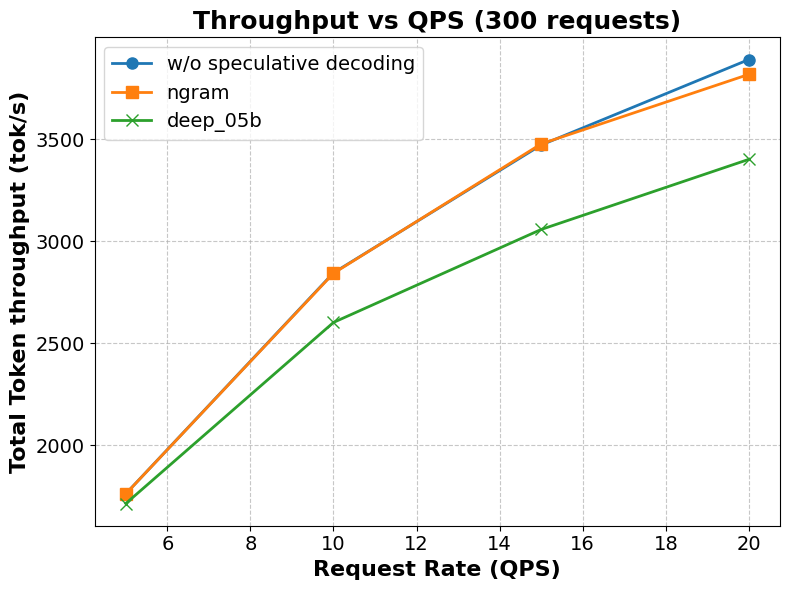

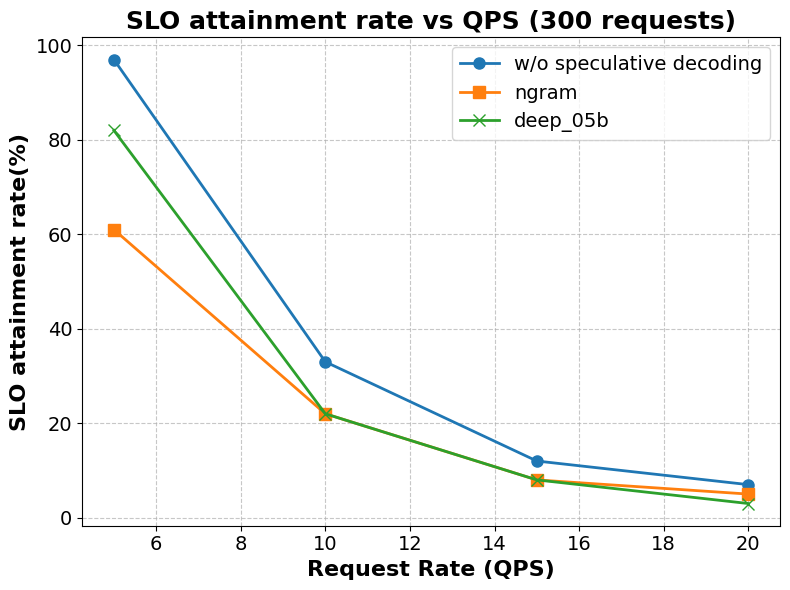

In [8]:
org=[1761.64,2844.59,3471.05,3890.10]
ngram=read_log('../logs3/deepseek_qps_ngram_300_new.log')[0]# disable 4 #[1745.38,2779.21,3346.87,3799.18] disable 32
print(ngram)
deep_05b=read_log('../logs3/deepseek_qps_deep_300_new.log')[0]#[1749.70,2571.08,3032.54,3304.90] disable 32
print(deep_05b)
for i, data in enumerate(ngram):
    print(data/deep_05b[i])
ngram_slo=[61,22,8,5]
org_slo=[97,33,12,7]
deep_05b_slo=[82,22,8,3]
datas = [org,ngram,deep_05b]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,[5,10,15,20],datas,names,title="Throughput vs QPS (300 requests)")
datas = [org_slo,ngram_slo,deep_05b_slo]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,[5,10,15,20],datas,names,ylabel='SLO attainment rate(%)',title="SLO attainment rate vs QPS (300 requests)")

In [ ]:
deep05b_throughput=[281.11,388.90,509.31,569.17]
ngram_throughput=[266.15,377.80,429.99,503.26]
nomal_throughput=[259.53,353.32,428.58,478.60] 
ngram_tpot=[21.97,26.27,25.56,30.40]
deep_tpot=[25.52,24.66,25.80,32.90]
nomal_tpot=[23.77,23.78,22.92,26.01]
datas = [nomal_throughput,ngram_throughput,deep05b_throughput]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,[1,2,4,8],datas,names,title="Throughput vs QPS (20 requests)")

datas = [nomal_tpot,ngram_tpot,deep_tpot]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,[1,2,4,8],datas,names,ylabel='P99 TPOT(ms)',title="P99 TPOT vs QPS (20 requests)")

In [ ]:
# 10 个请求 
qps=[0.1,0.3,0.6,1]
org_medium_e2e=[2864.90,2922.48,2966.53,3016.59]
org_throughput=[26.65,79.95,154.53,245.42]
deep_medium_e2e=[2222.05,2342.21,2526.13,2419.26]
deep_throughput=[26.64,79.93,156.07,251.95]
ngram_medium_e2e=[2219.63,2264.50,2337.76,2644.92]
ngram_throughput=[26.65,79.93,155.58,248.38]
datas = [org_throughput,ngram_throughput,deep_throughput]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,qps,datas,names,title="Throughput vs QPS (20 requests)")

datas = [org_medium_e2e,ngram_medium_e2e,deep_medium_e2e]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,qps,datas,names,ylabel='Mean E2EL (ms)',title="Mean E2EL vs QPS (20 requests)")

In [ ]:


qps=[1,2,4,8]
org_throughput,org_e2e = read_log('../logs3/deepseek_qps_org_10_new.log')
ngram_throughput,ngram_e2e = read_log('../logs3/deepseek_qps_ngram_10_new.log')
deep_throughput,deep_e2e = read_log('../logs3/deepseek_qps_deep_10_new.log')
datas = [org_throughput,ngram_throughput,deep_throughput]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,qps,datas,names,title="Throughput vs QPS (20 requests)")
datas = [org_e2e,ngram_e2e,deep_e2e]
names = ['w/o speculative decoding','ngram','deep_05b']
common_plt(plt,qps,datas,names,ylabel='Mean E2EL (ms)',title="Mean E2EL vs QPS (20 requests)")

NameError: name 'common_plt' is not defined

In [1]:
print("hello")

hello


1. 硬件感知 budget
2. 温度自适应  top k 或者 独立重分布 无重放 NO
3. batch
4. 长短文本 短测数据比较有效
5. 请求调度 优先级的问题
6. 异步
7. 禁用，动态卸载, 有两种原因是需要offload的，一个是超出长度，一个是batch size很大
8. 多proposer https://github.com/vllm-project/vllm/pull/7947